# Monte Carlo Player Projection Engine
### Vectorised FPL Points Simulation — Interactive Explorer


[![Launch Interactive Notebook on Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/vkenard/football-performance-analytics/main?labpath=mc_player_projection.ipynb)  
*One click — no account, no setup. Opens this notebook live in your browser.*

This notebook demonstrates the core simulation engine from the production football analytics pipeline.

**What the engine does.** For every player, every remaining fixture, and N iterations it simultaneously:

1. Draws `Bernoulli(start_prob)` — does the player feature?
2. Draws `Poisson(dc_lambda)` **team** goals from fixture-level Dixon-Coles parameters
3. Allocates individual goals/assists via `Binomial(team_goals, player_share)` — correctly modelling \
player output as *dependent on team output* (a player cannot score if their team scores 0)
4. Computes FPL points using a position-specific scoring dispatch table (no conditional branching)
5. Sums across fixtures to a full remaining-season distribution per player

All three dimensions — **players × fixtures × iterations** — live in a single \
`(n_players, n_fixtures, n_iterations)` tensor. No Python loops.

> **Interactive controls** are in Cell 5. Adjust availability, fixture difficulty, and \
iteration count, then click **Run Interact** to update.
>
> *Viewing on GitHub? Widgets require a live Jupyter kernel — scroll to Cell 7 for pre-rendered static output.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import ipywidgets as widgets
from IPython.display import display

np.random.seed(42)
pd.set_option("display.float_format", "{:.2f}".format)
print("Engine ready.")
print("  Run Cell 5 for the interactive explorer.")
print("  Scroll to Cell 7 for pre-rendered static output.")
print("  Requirements: numpy pandas matplotlib ipywidgets")

Engine ready.
  Run Cell 5 for the interactive explorer.
  Scroll to Cell 7 for pre-rendered static output.
  Requirements: numpy pandas matplotlib ipywidgets


## 1 — Base Parameters

These are the fixed structural inputs. Dixon-Coles lambdas represent expected goals *for* (`attack_lam`)
and *against* (`concede_lam`) per player's team for each remaining fixture.
The interactive controls scale these to simulate easier or harder run-ins.

| Parameter | Meaning |
|---|---|
| `attack_lam` | DC attack × opponent DC defence — expected team goals *for* |
| `concede_lam` | Opponent DC attack × team DC defence — expected team goals *against* |
| `start_prob` | Bernoulli probability of featuring — encodes injury/rotation/suspension risk |
| `goal_share` | Fraction of team goals attributed to this player (per-90 5-GW EWMA) |


In [2]:
# Remaining fixtures
fixtures = pd.DataFrame({
    "gw":    [33,              34,             35,              36,                  37],
    "label": ["vs Arsenal (H)","vs Wolves (A)","vs Palace (H)","vs Bournemouth (H)","vs Chelsea (A)"],
})
N_FIX = len(fixtures)

# DC lambdas: shape (n_players, n_fixtures)
# Players 0-1: strong attacking team | 2-3: balanced mid-table | 4-5: defensive team
BASE_ATTACK = np.array([
    [1.9, 1.2, 1.8, 1.6, 0.8],   # FWD — strong attack
    [1.9, 1.2, 1.8, 1.6, 0.8],   # MID — same team
    [1.3, 1.1, 1.4, 1.5, 0.9],   # DEF — balanced
    [1.3, 1.1, 1.4, 1.5, 0.9],   # MID — same team
    [0.8, 1.0, 0.9, 1.1, 0.7],   # GK  — defensive team
    [0.8, 1.0, 0.9, 1.1, 0.7],   # MID — same team
])
BASE_CONCEDE = np.array([
    [1.8, 1.0, 0.9, 0.7, 1.6],
    [1.8, 1.0, 0.9, 0.7, 1.6],
    [1.2, 0.8, 0.9, 1.0, 1.3],
    [1.2, 0.8, 0.9, 1.0, 1.3],
    [0.7, 0.9, 0.7, 0.8, 1.1],
    [0.7, 0.9, 0.7, 0.8, 1.1],
])

roster = pd.DataFrame({
    "name":         ["Elite Striker",    "Creative Midfielder", "Reliable Defender",
                     "Set-Piece Mid",    "Elite GK",           "Pacey Winger"],
    "pos":          ["FWD",              "MID",                "DEF",
                     "MID",             "GK",                 "MID"],
    "start_prob":   [0.95,              0.90,                 0.85,
                     0.75,             0.99,                 0.70],
    "goal_share":   [0.25,              0.10,                 0.04,
                     0.08,             0.00,                 0.12],
    "assist_share": [0.08,              0.18,                 0.05,
                     0.14,             0.00,                 0.15],
})
N_PLAY = len(roster)

# FPL scoring dispatch — (N_PLAY, 1, 1) broadcast arrays
GOAL_PTS   = {"GK": 6, "DEF": 6, "MID": 5, "FWD": 4}
CS_PTS     = {"GK": 4, "DEF": 4, "MID": 1, "FWD": 0}
ASSIST_PTS = 3
APP_PTS    = 2
goal_pts_v = np.array([GOAL_PTS[p] for p in roster["pos"]]).reshape(N_PLAY, 1, 1)
cs_pts_v   = np.array([CS_PTS[p]   for p in roster["pos"]]).reshape(N_PLAY, 1, 1)

print("Base parameters loaded.")
print(f"Players: {N_PLAY}  |  Remaining fixtures: {N_FIX}")
print(roster[["name", "pos", "start_prob", "goal_share", "assist_share"]].to_string(index=False))

Base parameters loaded.
Players: 6  |  Remaining fixtures: 5
               name pos  start_prob  goal_share  assist_share
      Elite Striker FWD        0.95        0.25          0.08
Creative Midfielder MID        0.90        0.10          0.18
  Reliable Defender DEF        0.85        0.04          0.05
      Set-Piece Mid MID        0.75        0.08          0.14
           Elite GK  GK        0.99        0.00          0.00
       Pacey Winger MID        0.70        0.12          0.15


## 2 — The Vectorised Simulation Engine

```
tensor shape: (6 players, 5 fixtures, N iterations)
```

**Step A** — `Bernoulli(start_prob)` availability mask
**Step B** — `Poisson(attack_lam)` team goals; `Poisson(concede_lam)` team concede
**Step C** — `Binomial(team_goals, goal_share)` individual goals/assists (respects team total)
**Step D** — clean sheet flag `(team_concede == 0)`
**Step E** — FPL points dispatch × availability mask
**Step F** — sum across fixtures → `(N_PLAY, N_ITER)` remaining-season distribution


In [3]:
def simulate(n_iter, start_probs, attack_lam, concede_lam):
    n_play, n_fix = attack_lam.shape

    # A: Bernoulli availability mask
    played = np.random.binomial(
        n=1, p=start_probs.reshape(n_play, 1, 1),
        size=(n_play, n_fix, n_iter),
    )
    # B: Poisson team goals from DC lambdas
    team_goals   = np.random.poisson(lam=attack_lam.reshape(n_play, n_fix, 1),
                                      size=(n_play, n_fix, n_iter))
    team_concede = np.random.poisson(lam=concede_lam.reshape(n_play, n_fix, 1),
                                      size=(n_play, n_fix, n_iter))
    # C: Binomial thinning — individual contributions depend on team total
    player_goals   = np.random.binomial(n=team_goals,   p=roster["goal_share"].values.reshape(n_play, 1, 1))
    player_assists = np.random.binomial(n=team_goals,   p=roster["assist_share"].values.reshape(n_play, 1, 1))
    # D: Clean sheet flag
    cs_flag = (team_concede == 0).astype(np.int8)
    # E: FPL points × availability mask
    pts_grid = (
        player_goals   * goal_pts_v +
        player_assists * ASSIST_PTS +
        cs_flag        * cs_pts_v   +
        APP_PTS
    ) * played
    # F: Sum across fixtures
    pts_remaining = pts_grid.sum(axis=1)   # (N_PLAY, n_iter)
    return pts_grid, pts_remaining


def _summary_df(pts_grid, pts_remaining):
    return pd.DataFrame({
        "Player":      roster["name"],
        "Pos":         roster["pos"],
        "Exp Pts":     pts_remaining.mean(axis=1).round(1),
        "P10 (floor)": np.percentile(pts_remaining, 10, axis=1).round(1),
        "P50 (median)":np.percentile(pts_remaining, 50, axis=1).round(1),
        "P90 (ceil)":  np.percentile(pts_remaining, 90, axis=1).round(1),
        "P(Blank GW)": (pts_grid.max(axis=2) <= APP_PTS).mean(axis=1).round(3),
    }).sort_values("Exp Pts", ascending=False).reset_index(drop=True)


def plot_results(pts_grid, pts_remaining, title_suffix=''):
    BG, PANEL  = '#0D1117', '#161B22'
    ACCENT, TEXT, DIM = '#58A6FF', '#E6EDF3', '#8B949E'
    POS_COL = {'GK': '#E3B341', 'DEF': '#3FB950', 'MID': '#58A6FF', 'FWD': '#F78166'}

    means  = pts_remaining.mean(axis=1)
    p10    = np.percentile(pts_remaining, 10, axis=1)
    p90    = np.percentile(pts_remaining, 90, axis=1)
    order  = np.argsort(means)[::-1]
    onames = roster['name'].values[order]
    omeans = means[order]; op10 = p10[order]; op90 = p90[order]
    ocols  = [POS_COL[roster['pos'].values[i]] for i in order]
    fm     = pts_grid.mean(axis=2)

    fig = plt.figure(figsize=(14, 11), facecolor=BG)
    n_it = pts_remaining.shape[1]
    title = f'Monte Carlo FPL Projection — {N_FIX} Fixtures | {n_it:,} iterations'
    if title_suffix: title += f'  |  {title_suffix}'
    fig.suptitle(title, color=TEXT, fontsize=13, fontweight='bold', y=0.98)
    gs = GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.32)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.set_facecolor(PANEL)
    for sp in ax1.spines.values(): sp.set_edgecolor('#30363D')
    y = range(N_PLAY)
    ax1.barh(y, omeans, color=ocols, alpha=0.80, height=0.52, zorder=3)
    ax1.hlines(y, op10, op90, color='white', linewidth=2.2, alpha=0.55, zorder=4)
    ax1.plot(op10, y, 'o', color='white', markersize=4.5, alpha=0.55, zorder=5)
    ax1.plot(op90, y, 'o', color='white', markersize=4.5, alpha=0.55, zorder=5)
    for i, (m, n) in enumerate(zip(omeans, onames)):
        ax1.text(m + 0.4, i, f'{m:.1f}', va='center', color=ocols[i],
                 fontsize=9.5, fontweight='bold')
    ax1.set_yticks(y); ax1.set_yticklabels(onames, color=TEXT, fontsize=9.5)
    ax1.set_xlabel('Projected FPL Points (remaining GWs)', color=DIM, fontsize=9)
    ax1.set_title('Expected Points with P10–P90 Uncertainty Band', color=ACCENT,
                  fontsize=11, fontweight='bold', pad=8)
    ax1.tick_params(colors=DIM)
    ax1.grid(axis='x', color='#30363D', linewidth=0.6, zorder=1)
    ax1.set_xlim(0, op90.max() + 7)
    patches = [mpatches.Patch(color=c, label=p) for p, c in POS_COL.items()]
    ax1.legend(handles=patches, loc='lower right',
               facecolor=PANEL, edgecolor='#30363D', labelcolor=TEXT, fontsize=8.5)

    ax2 = fig.add_subplot(gs[1, 0])
    ax2.set_facecolor(PANEL)
    for sp in ax2.spines.values(): sp.set_edgecolor('#30363D')
    for i, row in roster.iterrows():
        col = POS_COL[row['pos']]
        ax2.hist(pts_remaining[i], bins=35, density=True, alpha=0.45,
                 color=col, edgecolor='none', label=row['name'])
        ax2.axvline(pts_remaining[i].mean(), color=col, linewidth=1.4,
                    linestyle='--', alpha=0.9)
    ax2.set_title('Full Remaining-Season Distribution', color=ACCENT,
                  fontsize=10, fontweight='bold', pad=6)
    ax2.set_xlabel('Projected Points', color=DIM, fontsize=8.5)
    ax2.set_ylabel('Density', color=DIM, fontsize=8.5)
    ax2.tick_params(colors=DIM)
    ax2.legend(facecolor=PANEL, edgecolor='#30363D', labelcolor=TEXT,
               fontsize=7.5, loc='upper right')

    ax3 = fig.add_subplot(gs[1, 1])
    ax3.set_facecolor(PANEL)
    im = ax3.imshow(fm, cmap='YlOrRd', aspect='auto', vmin=0)
    ax3.set_xticks(range(N_FIX))
    ax3.set_xticklabels(fixtures['label'], rotation=28, ha='right', color=DIM, fontsize=7.5)
    ax3.set_yticks(range(N_PLAY))
    ax3.set_yticklabels(roster['name'], color=TEXT, fontsize=8)
    ax3.set_title('Expected Pts per Gameweek', color=ACCENT,
                  fontsize=10, fontweight='bold', pad=6)
    thresh = fm.max() * 0.55
    for i in range(N_PLAY):
        for j in range(N_FIX):
            ax3.text(j, i, f'{fm[i, j]:.1f}', ha='center', va='center',
                     color='black' if fm[i, j] > thresh else TEXT,
                     fontsize=7.5, fontweight='bold')
    cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors=DIM, labelsize=7)
    cbar.set_label('Exp Pts', color=DIM, fontsize=7.5)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

print("simulate(), _summary_df(), plot_results() defined.")

simulate(), _summary_df(), plot_results() defined.


## 3 — Interactive Explorer

Adjust the sliders, then click **Run Interact**.

| Slider group | What it controls |
|---|---|
| **Iterations** | Sample size — more = smoother distributions |
| **Availability (per player)** | `Bernoulli(p)` probability of featuring |
| **Attack λ scale** | Uniform multiplier on all DC attack lambdas (>1 = easier schedule offensively) |
| **Concede λ scale** | Uniform multiplier on all DC concede lambdas (>1 = harder schedule defensively) |

> **Note:** Widgets require a live Jupyter kernel. Static pre-rendered output is in Cell 6.


In [4]:
def _run_interactive(
    n_iter,
    avail_striker, avail_creative_mid, avail_defender,
    avail_setpiece_mid, avail_gk, avail_winger,
    attack_scale, concede_scale,
):
    start_probs = np.array([
        avail_striker, avail_creative_mid, avail_defender,
        avail_setpiece_mid, avail_gk, avail_winger,
    ])
    pts_grid, pts_remaining = simulate(
        n_iter, start_probs,
        BASE_ATTACK  * attack_scale,
        BASE_CONCEDE * concede_scale,
    )
    display(_summary_df(pts_grid, pts_remaining))
    plot_results(pts_grid, pts_remaining,
                 title_suffix=f'atk×{attack_scale:.1f}  def×{concede_scale:.1f}')


_s = dict(continuous_update=False,
          style={'description_width': '180px'},
          layout=widgets.Layout(width='500px'))

widgets.interact_manual(
    _run_interactive,
    n_iter=widgets.IntSlider(
        min=1_000, max=20_000, step=1_000, value=10_000,
        description='Iterations', **_s),
    avail_striker=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.95,
        description='Elite Striker avail', **_s),
    avail_creative_mid=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.90,
        description='Creative Mid avail', **_s),
    avail_defender=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.85,
        description='Defender avail', **_s),
    avail_setpiece_mid=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.75,
        description='Set-Piece Mid avail', **_s),
    avail_gk=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.99,
        description='Elite GK avail', **_s),
    avail_winger=widgets.FloatSlider(
        min=0.0, max=1.0, step=0.05, value=0.70,
        description='Pacey Winger avail', **_s),
    attack_scale=widgets.FloatSlider(
        min=0.5, max=2.0, step=0.1, value=1.0,
        description='Attack λ scale', **_s),
    concede_scale=widgets.FloatSlider(
        min=0.5, max=2.0, step=0.1, value=1.0,
        description='Concede λ scale', **_s),
)

interactive(children=(IntSlider(value=10000, continuous_update=False, description='Iterations', layout=Layout(�

<function __main__._run_interactive(n_iter, avail_striker, avail_creative_mid, avail_defender, avail_setpiece_mid, avail_gk, avail_winger, attack_scale, concede_scale)>

## 4 — Static Output (GitHub Fallback)

Pre-rendered at default parameters: 10,000 iterations, base DC lambdas, all availability at roster defaults.


Expected FPL Points — Remaining 5 Fixtures  (n=10,000 iterations)
             Player Pos  Exp Pts  P10 (floor)  P50 (median)  P90 (ceil)  P(Blank GW)
           Elite GK  GK    18.60        14.00         18.00       26.00         0.00
      Elite Striker FWD    18.10        10.00         18.00       26.00         0.00
Creative Midfielder MID    17.40        10.00         17.00       26.00         0.00
  Reliable Defender DEF    16.70        10.00         16.00       24.00         0.00
      Set-Piece Mid MID    12.70         7.00         12.00       20.00         0.00
       Pacey Winger MID    11.80         6.00         11.00       19.00         0.00


C:\Users\bigke\AppData\Local\Temp\ipykernel_7960\734960551.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


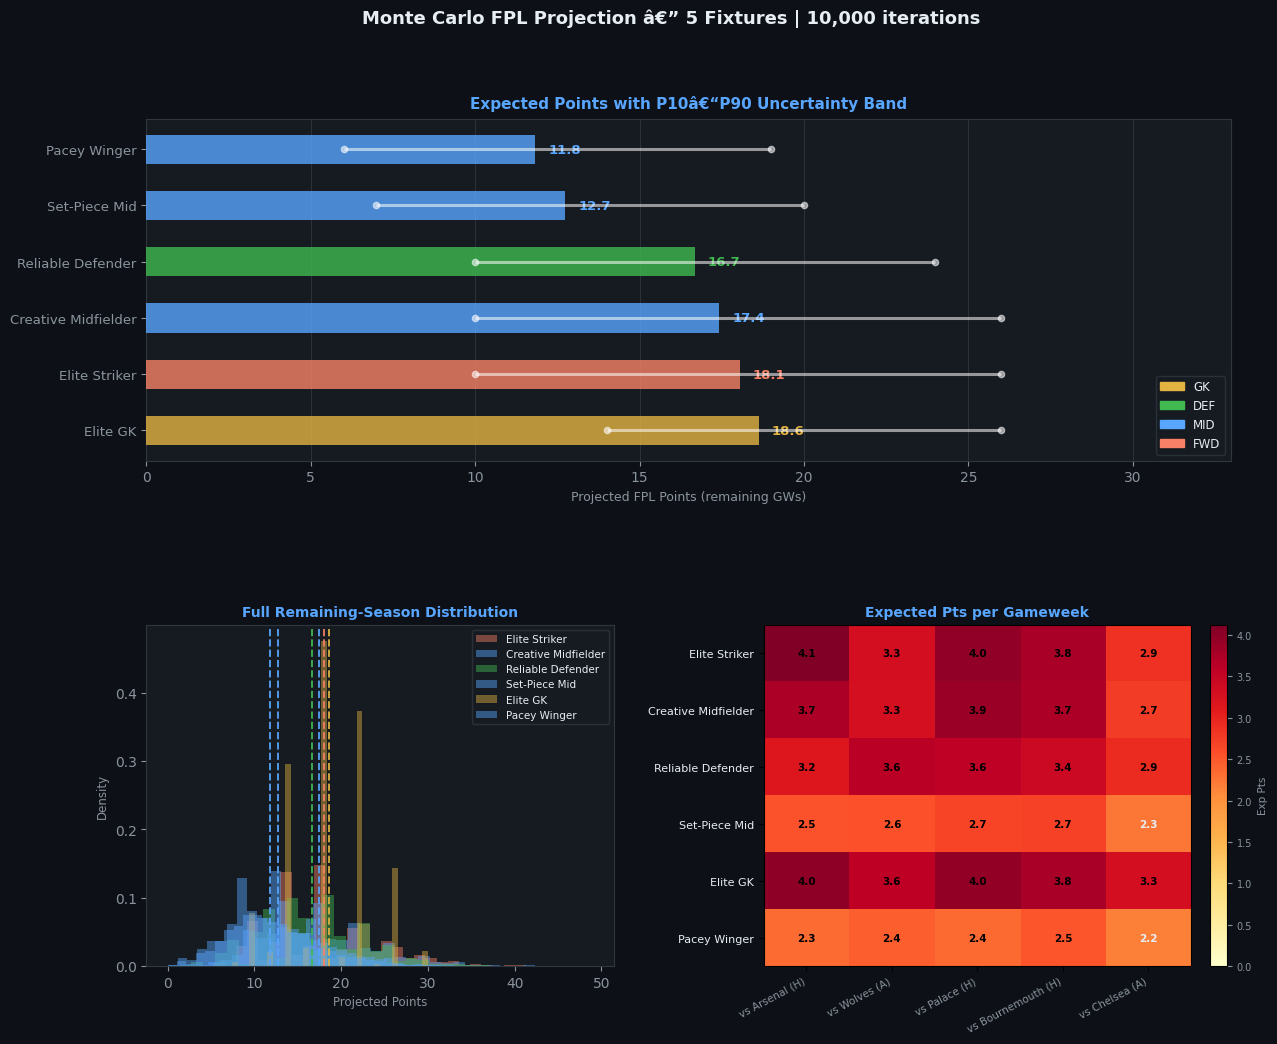

In [5]:
np.random.seed(42)
pts_grid_s, pts_rem_s = simulate(
    n_iter=10_000,
    start_probs=roster['start_prob'].values,
    attack_lam=BASE_ATTACK,
    concede_lam=BASE_CONCEDE,
)
print('Expected FPL Points — Remaining 5 Fixtures  (n=10,000 iterations)')
print('=' * 65)
print(_summary_df(pts_grid_s, pts_rem_s).to_string(index=False))
plot_results(pts_grid_s, pts_rem_s)

## 5 — Connection to the Production System

| This notebook | Production system |
|---|---|
| 6 synthetic players | 378 active Premier League players |
| 5 remaining fixtures | Dynamic — updates weekly as fixtures settle |
| Pre-set DC lambdas | Refitted weekly: rolling DC on last 38+ matches, exponential decay |
| Fixed `start_prob` | Updated from FPL ownership data, injury API, and press-conference signals |
| Uniform λ scale slider | Per-fixture per-team DC refits — each fixture has its own attack/concede pair |
| 10,000 iterations | 10,000 — sufficient for stable percentiles at this player count |

**Why Binomial thinning, not independent Poisson per player?**
A naive approach assigns each player their own independent Poisson draw. This is wrong: it allows
player A and player B to both score even when the team Poisson draw produces 0 goals.
`Binomial(n=team_goals, p=goal_share)` correctly propagates the team-level constraint down to individuals.

**Why the 3-D tensor?**
At 378 players × 8 remaining fixtures × 10,000 iterations = 30.2 million simulation cells,
the vectorised approach runs in under two seconds on a standard laptop CPU.
Adding 50 more players or 3 more fixtures costs one reshape operation, not additional loop iterations.
